In [68]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchtext.datasets import Multi30k
from torchtext.data import Field, BucketIterator, Example, Dataset
import numpy as np
import spacy
import random
import torchtext.datasets as datasets
import os
import urllib.request
import gzip
import shutil
import torchinfo

In [69]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
DATA_URLS = {
    "train.de": "https://github.com/multi30k/dataset/raw/master/data/task1/raw/train.de.gz",
    "train.en": "https://github.com/multi30k/dataset/raw/master/data/task1/raw/train.en.gz",
    "val.de": "https://github.com/multi30k/dataset/raw/master/data/task1/raw/val.de.gz",
    "val.en": "https://github.com/multi30k/dataset/raw/master/data/task1/raw/val.en.gz",
    "test.de": "https://github.com/multi30k/dataset/raw/master/data/task1/raw/test_2016_flickr.de.gz",
    "test.en": "https://github.com/multi30k/dataset/raw/master/data/task1/raw/test_2016_flickr.en.gz",
}

DATA_DIR = "multi30k"

# Step 1: Download and Extract Data
def download_and_extract():
    os.makedirs(DATA_DIR, exist_ok=True)
    for filename, url in DATA_URLS.items():
        gz_file = os.path.join(DATA_DIR, filename + ".gz")
        txt_file = os.path.join(DATA_DIR, filename)

        # Download file if it doesn't exist
        if not os.path.exists(txt_file):
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, gz_file)

            # Extract file
            with gzip.open(gz_file, "rb") as f_in, open(txt_file, "wb") as f_out:
                shutil.copyfileobj(f_in, f_out)
            os.remove(gz_file)
            print(f"Extracted {filename}")

# Step 2: Load Data into PyTorch Dataset
def load_dataset(src_file, trg_file, src_field, trg_field):
    examples = []
    with open(src_file, "r", encoding="utf-8") as src_f, open(trg_file, "r", encoding="utf-8") as trg_f:
        for src, trg in zip(src_f, trg_f):
            examples.append(Example.fromlist([src.strip(), trg.strip()], fields=[("src", src_field), ("trg", trg_field)]))
    return Dataset(examples, fields={"src": src_field, "trg": trg_field})

# Step 3: Define Tokenizers
german = Field(tokenize="spacy", tokenizer_language="de_core_news_sm", lower=True, init_token = "<sos>", eos_token = "<eos>")
english = Field(tokenize="spacy", tokenizer_language="en_core_web_sm", lower=True, init_token = "<sos>", eos_token = "<eos>")

# Download, extract, and load dataset
download_and_extract()

train_data = load_dataset(os.path.join(DATA_DIR, "train.de"), os.path.join(DATA_DIR, "train.en"), german, english)
val_data = load_dataset(os.path.join(DATA_DIR, "val.de"), os.path.join(DATA_DIR, "val.en"), german, english)
test_data = load_dataset(os.path.join(DATA_DIR, "test.de"), os.path.join(DATA_DIR, "test.en"), german, english)

print(f"Train samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Test samples: {len(test_data)}")

# Step 4: Create DataLoader for Training
BATCH_SIZE = 32
train_iterator, val_iterator, test_iterator = BucketIterator.splits(
    (train_data, val_data, test_data),
    batch_size=BATCH_SIZE,
    device="cuda" if torch.cuda.is_available() else "cpu",
    sort_within_batch=True,
    sort_key=lambda x: len(x.src)
)

print("Data loading complete! ✅")


Train samples: 29000
Validation samples: 1014
Test samples: 1000
Data loading complete! ✅


In [71]:
german.build_vocab(train_data, max_size = 10000, min_freq = 1)
english.build_vocab(train_data, max_size = 10000, min_freq = 1)

![Screenshot from 2025-04-03 04-36-00.png](<attachment:Screenshot from 2025-04-03 04-36-00.png>)

![Screenshot from 2025-04-03 04-38-54.png](<attachment:Screenshot from 2025-04-03 04-38-54.png>)
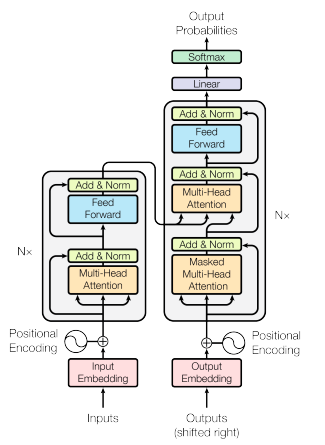
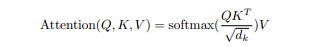

In [72]:
class SelfAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super(SelfAttention, self).__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size//heads

        assert (self.head_dim*heads == embed_size), "embed_size needs to be divisible the heads"

        self.values = nn.Linear(self.head_dim, self.head_dim, bias = False)
        self.keys = nn.Linear(self.head_dim, self.head_dim, bias = False)
        self.queries = nn.Linear(self.head_dim, self.head_dim, bias = False)
        self.fc = nn.Linear(heads*self.head_dim, embed_size)

    def forward(self, values, keys, queries, mask):
        ## values shape -> (N, seq_len, embed_size) ## same for queries and keys
        N = queries.shape[0] ## Number of training examples we are sending in at a time
        value_len, key_len, query_len = values.shape[1], keys.shape[1], queries.shape[1]

        values = values.reshape(N, value_len, self.heads, self.head_dim) ## Splitting embed_size into heads*head_dim
        keys = keys.reshape(N, key_len, self.heads, self.head_dim)
        queries = queries.reshape(N, query_len, self.heads, self.head_dim)

        values = self.values(values)
        queries = self.queries(queries)
        keys = self.keys(keys)

        energy = torch.einsum("nqhd,nkhd->nhqk", [queries, keys]) ## Using this for easy matrix multiplication instead of using tedious method of using torch.bmm
        ## We want energy to be of shape -> (N, heads, query_len, key_len)

        if mask is not None:
            energy = energy.masked_fill(mask == 0, float("-1e20")) ## If any zero value is found in mask then replace it with a very small value

        attention = torch.softmax(energy/((self.embed_size)**(1/2)), dim = 3)
        ## attention shape -> (N, heads, query_len, key_len)

        out = torch.einsum("nhql,nlhd->nqhd", [attention, values]) ## Here, the key_len and the val_len are always assumed to be same and are denoted by "l"
        ## out shape -> (N, query_len, heads, head_dim)
        out = out.reshape(N, query_len, self.heads*self.head_dim)

        out = self.fc(out)
        return out

In [73]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_size, heads, dropout, forward_expansion):
        super(TransformerBlock, self).__init__()
        self.attention = SelfAttention(embed_size, heads)
        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)

        self.feed_forward = nn.Sequential(
            nn.Linear(embed_size, forward_expansion*embed_size),
            nn.ReLU(),
            nn.Linear(forward_expansion*embed_size, embed_size)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, value, key, query, mask):
        attention = self.attention(value, key, query, mask)

        x = self.dropout(self.norm1(attention+query))
        
        forward = self.feed_forward(x)
        out = self.dropout(self.norm2(forward+x))
        return out

In [74]:
class Encoder(nn.Module):
    def __init__(self, src_vocab_size, embed_size, num_layers, heads, device, forward_expansion, dropout, max_length):
        super(Encoder, self).__init__()
        self.embed_size = embed_size
        self.device = device
        self.word_embedding = nn.Embedding(src_vocab_size, embed_size)
        self.positional_embedding = nn.Embedding(max_length, embed_size)

        self.layers = nn.ModuleList(
            [
                TransformerBlock(embed_size, heads, dropout, forward_expansion) for _ in range(num_layers)
            ]
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        N, seq_len = x.shape
        positions = torch.arange(0, seq_len).expand(N, seq_len).to(self.device)

        out = self.dropout(self.word_embedding(x) + self.positional_embedding(positions))

        for layer in self.layers:
            out = layer(out, out, out, mask)

        return out

In [75]:
class DecoderBlock(nn.Module):
    def __init__(self, embed_size, heads, forward_expansion, dropout, device):
        super(DecoderBlock, self).__init__()
        self.attention = SelfAttention(embed_size, heads)
        self.norm = nn.LayerNorm(embed_size)
        self.transformerblock = TransformerBlock(embed_size, heads, dropout, forward_expansion)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, value, key, src_mask, trg_mask):
        
        attention = self.attention(x, x, x, trg_mask)
        query = self.dropout(self.norm(attention+x))
        out = self.transformerblock(value, key, query, src_mask)
        return out

In [76]:
class Decoder(nn.Module):
    def __init__(self, trg_vocab_size, embed_size, num_layers, heads, forward_expansion, dropout, device, max_length):
        super(Decoder, self).__init__()
        self.device = device
        self.word_embedding = nn.Embedding(trg_vocab_size, embed_size)
        self.positional_embedding = nn.Embedding(max_length, embed_size)

        self.layers = nn.ModuleList(
            [DecoderBlock(embed_size, heads, forward_expansion, dropout, device) for _ in range(num_layers)]
        )

        self.fc_out = nn.Linear(embed_size, trg_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask, trg_mask):
        N, seq_len = x.shape
        positions = torch.arange(0, seq_len).expand(N, seq_len).to(self.device)
        x = self.dropout((self.word_embedding(x) + self.positional_embedding(positions)))

        for layer in self.layers:
            x = layer(x, enc_out, enc_out, src_mask, trg_mask)

        out = self.fc_out(x)
        return out

In [77]:
class Transformer(nn.Module):
    def __init__(self,
                 src_vocab_size, trg_vocab_size,
                 src_pad_idx, trg_pad_idx,
                 embed_size = 256,
                 num_layers = 6,
                 forward_expansion = 4,
                 heads = 8,
                 dropout = 0,
                 device = "cuda",
                 max_length = 100):
        super(Transformer, self).__init__()
        
        self.encoder = Encoder(src_vocab_size, embed_size, num_layers, heads, device, forward_expansion, dropout, max_length)
        self.decoder = Decoder(trg_vocab_size, embed_size, num_layers, heads, forward_expansion, dropout, device, max_length)

        self.src_pad_idx = src_pad_idx
        self.trg_pad_idx = trg_pad_idx
        self.device = device

    def make_src_mask(self, src):
        src_mask = (src != self.src_pad_idx).unsqueeze(1).unsqueeze(2)
        return src_mask.to(self.device)
    
    def make_trg_mask(self, trg):
        N, trg_len = trg.shape
        trg_mask = torch.tril(torch.ones((trg_len, trg_len))).expand(N, 1, trg_len, trg_len) ## "tril" is use to get lower triangular matrix which is being expanded to some shape
        return trg_mask.to(self.device)
    
    def forward(self, src, trg):
        src_mask = self.make_src_mask(src)
        trg_mask = self.make_trg_mask(trg)
        enc_src = self.encoder(src, src_mask)
        out = self.decoder(trg, enc_src, src_mask, trg_mask)
        return out

In [78]:
num_epochs = 100
learning_rate = 0.001
batch_size = 64

In [79]:
load_model = True
input_size_encoder = len(english.vocab)
input_size_decoder = len(german.vocab)
output_size = len(german.vocab)
embedding_size = 256
hidden_size = 512
num_layers = 6
forward_expansion = 4
heads = 8
dropout = 0.5

In [80]:
train_iterator, valid_iterator, test_iterator = BucketIterator.splits((train_data, val_data, test_data), batch_size = batch_size, sort_within_batch = True, sort_key = lambda x: len(x.src), device = device)

In [81]:
src_pad_idx = english.vocab.stoi["<pad>"]
trg_pad_idx = german.vocab.stoi["<pad>"]

In [82]:
model = Transformer(
    input_size_encoder, input_size_decoder,
    src_pad_idx, trg_pad_idx,
    embedding_size,
    num_layers,
    forward_expansion,
    heads,
    dropout,
    device
).to(device)

In [83]:
criterion = nn.CrossEntropyLoss(ignore_index = src_pad_idx)
optimizer = optim.Adam(model.parameters(), lr = learning_rate)

In [84]:
for epoch in range(num_epochs):
    print(f"Training epoch {epoch+1}/{num_epochs}")
    losses = []

    for batch_idx, batch in enumerate(train_iterator):
        inp_data = batch.src.to(device)
        target = batch.trg.to(device)
        inp_data = torch.clamp(inp_data, max = input_size_encoder - 1)

        '''print(inp_data.shape, target.shape)
        print(torch.max(inp_data))'''
        inp_data = inp_data.permute(1, 0)
        target = target.permute(1, 0)
        output = model(inp_data, target)
        ## output shape -> (trg_len, batch_size, output_dim)

        output = output[1:].reshape(-1, output.shape[2])
        target = target[1:].reshape(-1)

        optimizer.zero_grad()
        loss = criterion(output, target)
        losses.append(loss.item())
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = 1) ## to prevent exploding gradient problem

        optimizer.step()
    torch.save(model.state_dict(), "TransformerModel.pt")
    print(f"Loss: {np.mean(np.array(losses))}")
    

Training epoch 1/100
Loss: 5.533895903221836
Training epoch 2/100
Loss: 5.112376218325241
Training epoch 3/100
Loss: 4.936775648646417
Training epoch 4/100
Loss: 4.898058328334455
Training epoch 5/100
Loss: 4.874746173488936
Training epoch 6/100
Loss: 4.858961554875983
Training epoch 7/100
Loss: 4.84591804937119
Training epoch 8/100
Loss: 4.827166186555367
Training epoch 9/100
Loss: 4.819805814306116
Training epoch 10/100
Loss: 4.811059317399752
Training epoch 11/100
Loss: 4.807620186112525
Training epoch 12/100
Loss: 4.7980667326418835
Training epoch 13/100
Loss: 4.793421327280053
Training epoch 14/100
Loss: 4.786798336432369
Training epoch 15/100
Loss: 4.7821633731741215
Training epoch 16/100
Loss: 4.771789311312369
Training epoch 17/100
Loss: 4.770665177164624
Training epoch 18/100
Loss: 4.766065217324815
Training epoch 19/100
Loss: 4.760976934222923
Training epoch 20/100
Loss: 4.755762557101145
Training epoch 21/100
Loss: 4.76294243388239
Training epoch 22/100
Loss: 4.7548788444586